# 🚗 Personalized Automobile Recommendation System
**JIIT Noida — AIML Lab (24B15CS222)**  
Team: Mohd Kashif Khan · Harshita Singhal · Ashmi Verma · Vanshik Jain  
Submitted to: Ms. Ambalika Sarkar

---
## Contents
1. Data Loading & Exploration
2. Data Preprocessing
3. Feature Engineering
4. Model 1 — KNN (K-Nearest Neighbours)
5. Model 2 — Cosine Similarity
6. Model 3 — K-Means Clustering
7. Evaluation
8. Save Artefacts

## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')

df_raw = pd.read_csv('../data/cars.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (5975, 14)


,Unnamed: 0,Name,Manufacturer,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine CC,Power,Seats,Mileage Km/L,Price
0,0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,72000,CNG,Manual,First,998,58.16,5,26.60,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,41000,Diesel,Manual,First,1582,126.20,5,19.67,12.50
2,2,Honda Jazz V,Honda,Chennai,2011,46000,Petrol,Manual,First,1199,88.70,5,18.20,4.50
3,3,Maruti Ertiga VDI,Maruti,Chennai,2012,87000,Diesel,Manual,First,1248,88.76,7,20.77,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,40670,Diesel,Automatic,Second,1968,140.80,5,15.20,17.74


In [2]:
print('Columns:', df_raw.columns.tolist())
print('\nNull counts:')
print(df_raw.isnull().sum())
print('\nData types:')
print(df_raw.dtypes)

Columns: ['Unnamed: 0', 'Name', 'Manufacturer', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine CC', 'Power', 'Seats', 'Mileage Km/L', 'Price']

Null counts:
Unnamed: 0           0
Name                 0
Manufacturer         0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Engine CC            0
Power                0
Seats                0
Mileage Km/L         0
Price                0
dtype: int64

Data types:
Unnamed: 0             int64
Name                  object
Manufacturer          object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Engine CC              int64
Power                float64
Seats                  int64
Mileage Km/L         float64
Price                float64
dtype: object


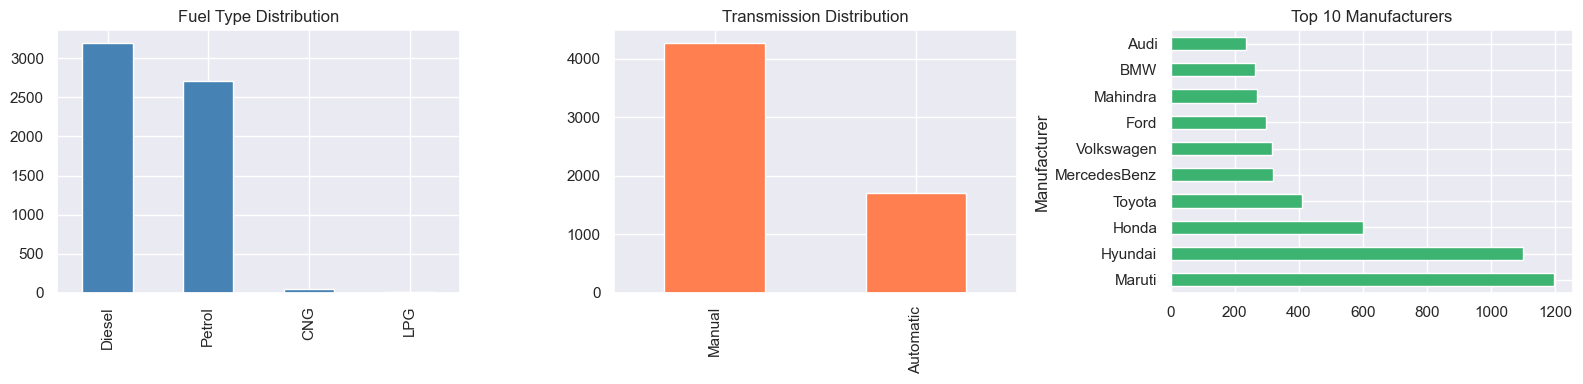

In [3]:
# Distribution of key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_raw['Fuel_Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Fuel Type Distribution')
axes[0].set_xlabel('')

df_raw['Transmission'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Transmission Distribution')
axes[1].set_xlabel('')

df_raw['Manufacturer'].value_counts().head(10).plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 10 Manufacturers')

plt.tight_layout()
plt.show()

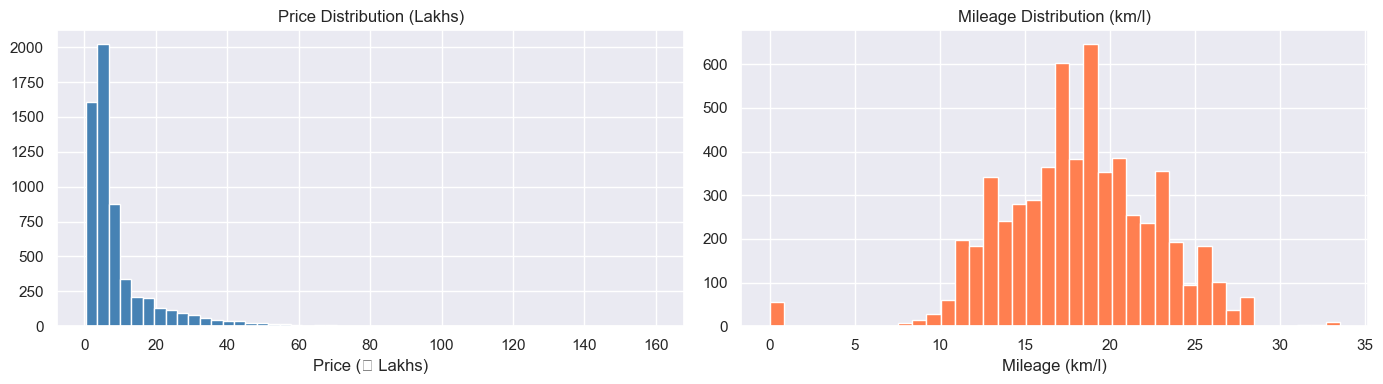

In [4]:
# Price & Mileage distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Lakhs)')
axes[0].set_xlabel('Price (₹ Lakhs)')

axes[1].hist(df_raw['Mileage Km/L'].dropna(), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Mileage Distribution (km/l)')
axes[1].set_xlabel('Mileage (km/l)')

plt.tight_layout()
plt.show()

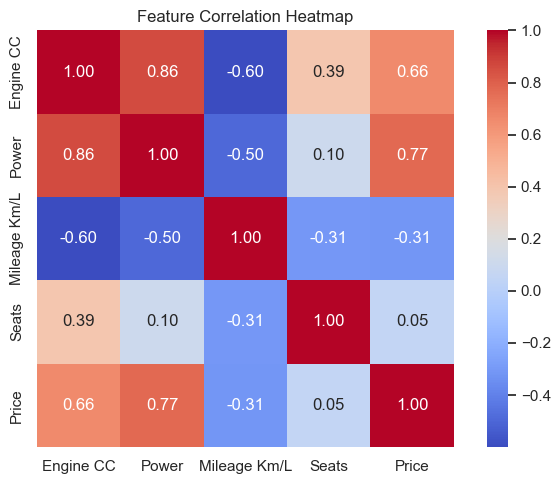

In [5]:
# Correlation heatmap (numeric columns)
numeric_cols = ['Engine CC', 'Power', 'Mileage Km/L', 'Seats', 'Price']
corr = df_raw[numeric_cols].dropna().corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [6]:
RENAME_MAP = {'Engine CC': 'Engine(CC)', 'Mileage Km/L': 'Mileage(Km/L)'}
FEATURE_COLS = ['Manufacturer', 'Fuel_Type', 'Transmission',
                'Engine(CC)', 'Mileage(Km/L)', 'Seats', 'Price']

df = df_raw.rename(columns=RENAME_MAP)

# Drop LPG — too few samples
df = df[df['Fuel_Type'] != 'LPG']

# Normalise manufacturer casing
df['Manufacturer'] = df['Manufacturer'].str.title()

# Keep relevant columns
df = df[['Name'] + FEATURE_COLS]

# Remove unrealistic seat counts
df = df[df['Seats'] <= 7]

# Drop NaN rows in key features
df = df.dropna(subset=FEATURE_COLS)
df = df.reset_index(drop=True)

print(f'Clean dataset shape: {df.shape}')
df.describe()

Clean dataset shape: (5823, 8)


,Engine(CC),Mileage(Km/L),Seats,Price
count,5823.000000,5823.000000,5823.000000,5823.000000
mean,1607.744633,18.301954,5.210716,9.567788
std,596.435198,4.486743,0.685579,11.321454
min,624.000000,0.000000,0.000000,0.440000
25%,1197.000000,15.500000,5.000000,3.500000
50%,1461.000000,18.480000,5.000000,5.650000
75%,1968.000000,21.100000,5.000000,10.000000
max,5998.000000,33.540000,7.000000,160.000000


## 3. Feature Engineering

In [7]:
from sklearn.preprocessing import MinMaxScaler

CATEGORICAL_COLS = ['Manufacturer', 'Fuel_Type', 'Transmission']

X = df[FEATURE_COLS].copy()
X = pd.get_dummies(X, columns=CATEGORICAL_COLS)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f'Feature matrix shape: {X_scaled.shape}')
X_scaled_df.head()

Feature matrix shape: (5823, 39)


,Engine(CC),Mileage(Km/L),Seats,Price,Manufacturer_Ambassador,Manufacturer_Audi,Manufacturer_Bentley,Manufacturer_Bmw,Manufacturer_Chevrolet,Manufacturer_Datsun,...,Manufacturer_Smart,Manufacturer_Tata,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
0,0.069594,0.793083,0.714286,0.008210,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.178266,0.586464,0.714286,0.075583,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.106997,0.542636,0.714286,0.025445,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.116115,0.619261,1.000000,0.034846,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.250093,0.453190,0.714286,0.108423,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 4. Model 1 — KNN (K-Nearest Neighbours)

In [8]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(n_neighbors=10, metric='euclidean', algorithm='ball_tree')
knn_model.fit(X_scaled)
print('KNN model trained on', X_scaled.shape[0], 'samples')

KNN model trained on 5823 samples


In [9]:
def recommend_knn(user_input, df, model, scaler, X_columns, n=5):
    """
    Recommend cars using KNN with hard categorical filters.
    """
    user_df = pd.DataFrame([user_input])
    user_df = pd.get_dummies(user_df)
    user_df = user_df.reindex(columns=X_columns, fill_value=0)
    user_vec = scaler.transform(user_df)

    # Get generous pool
    pool = min(len(df), 50)
    distances, indices = model.kneighbors(user_vec, n_neighbors=pool)
    neighbours = indices[0]

    # Hard filters
    mask = pd.Series([True] * len(df))
    for col, key in [('Manufacturer','Manufacturer'),
                     ('Fuel_Type','Fuel_Type'),
                     ('Transmission','Transmission')]:
        val = user_input.get(key)
        if val:
            candidate = mask & (df[col] == val)
            if candidate.any():
                mask = candidate

    valid_idx = set(df[mask].index)
    valid = [i for i in neighbours if i in valid_idx]
    chosen = valid[:n] if valid else list(neighbours[:n])

    return df.iloc[chosen].drop_duplicates(subset='Name').head(n)


# Example
user_input_knn = {
    'Manufacturer': 'Maruti',
    'Fuel_Type':    'Petrol',
    'Transmission': 'Manual',
    'Engine(CC)':   1200,
    'Mileage(Km/L)': 20.0,
    'Seats':         5,
    'Price':         5.0,
}

knn_results = recommend_knn(user_input_knn, df, knn_model, scaler, X.columns)
print('KNN Recommendations:')
knn_results[['Name', 'Fuel_Type', 'Transmission', 'Engine(CC)', 'Mileage(Km/L)', 'Price']]

KNN Recommendations:


,Name,Fuel_Type,Transmission,Engine(CC),Mileage(Km/L),Price
2852,Maruti Swift VXI BSIV,Petrol,Manual,1197,20.4,5.00
3310,Maruti Swift ZXI,Petrol,Manual,1197,20.4,4.95
1441,Maruti Swift VXI Optional,Petrol,Manual,1197,20.4,5.27


## 5. Model 2 — Cosine Similarity

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_cosine(user_input, df, n=5):
    """
    Recommend cars using Cosine Similarity on numeric features.
    Hard categorical filters applied first.
    """
    NUMERIC = ['Engine(CC)', 'Mileage(Km/L)', 'Seats', 'Price']

    # Hard filters
    filtered = df.copy()
    for col, key in [('Manufacturer','Manufacturer'),
                     ('Fuel_Type','Fuel_Type'),
                     ('Transmission','Transmission')]:
        val = user_input.get(key)
        if val:
            candidate = filtered[filtered[col] == val]
            if not candidate.empty:
                filtered = candidate

    if filtered.empty:
        return filtered

    # Scale numeric features together with user vector
    user_vec = np.array([[user_input.get(c, 0) for c in NUMERIC]], dtype=float)
    num_matrix = filtered[NUMERIC].values.astype(float)

    _scaler = MinMaxScaler()
    combined_scaled = _scaler.fit_transform(np.vstack([num_matrix, user_vec]))
    data_s, user_s = combined_scaled[:-1], combined_scaled[-1:]

    sims = cosine_similarity(user_s, data_s)[0]
    filtered = filtered.copy()
    filtered['similarity_score'] = (sims * 100).round(2)

    return (filtered
            .drop_duplicates(subset='Name')
            .sort_values('similarity_score', ascending=False)
            .head(n)
            .reset_index(drop=True))


# Example (same user preferences)
cosine_results = recommend_cosine(user_input_knn, df)
print('Cosine Similarity Recommendations:')
cosine_results[['Name', 'Fuel_Type', 'Transmission', 'Engine(CC)',
                'Mileage(Km/L)', 'Price', 'similarity_score']]

Cosine Similarity Recommendations:


,Name,Fuel_Type,Transmission,Engine(CC),Mileage(Km/L),Price,similarity_score
0,Maruti Swift Dzire VXI,Petrol,Manual,1197,20.85,5.25,99.98
1,Maruti Swift LXI,Petrol,Manual,1197,18.60,4.65,99.96
2,Maruti Swift Dzire VXI Optional,Petrol,Manual,1197,20.85,4.80,99.94
3,Maruti Swift VVT VXI,Petrol,Manual,1197,22.00,5.43,99.94
4,Maruti Swift ZXI,Petrol,Manual,1197,18.60,4.45,99.92


## 6. Model 3 — K-Means Clustering

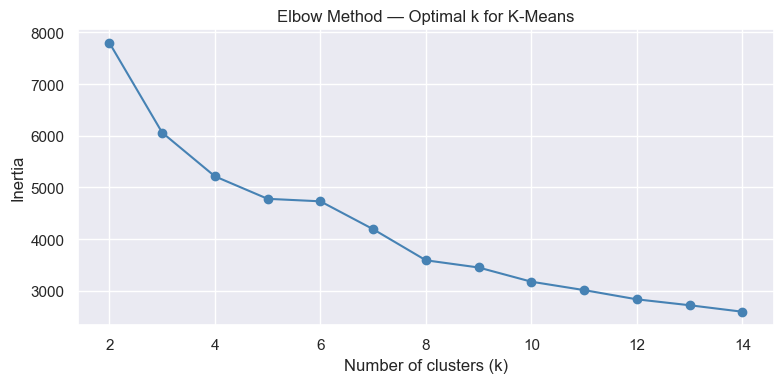

In [11]:
from sklearn.cluster import KMeans

# Elbow method to find optimal k
inertias = []
K_range  = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k for K-Means')
plt.tight_layout()
plt.show()

In [12]:
# Fit K-Means with chosen k
OPTIMAL_K = 6
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster profile
cluster_profile = df.groupby('cluster').agg(
    count        = ('Name', 'count'),
    avg_price    = ('Price', 'mean'),
    avg_mileage  = ('Mileage(Km/L)', 'mean'),
    avg_engine   = ('Engine(CC)', 'mean'),
).round(2)
cluster_profile

,count,avg_price,avg_mileage,avg_engine
cluster,,,,
0,2092,4.12,18.00,1238.23
1,717,6.13,20.77,1490.47
2,609,11.26,15.76,1747.12
3,1094,24.72,15.74,2290.31
4,921,5.31,23.02,1360.61
5,390,10.02,15.40,2256.73


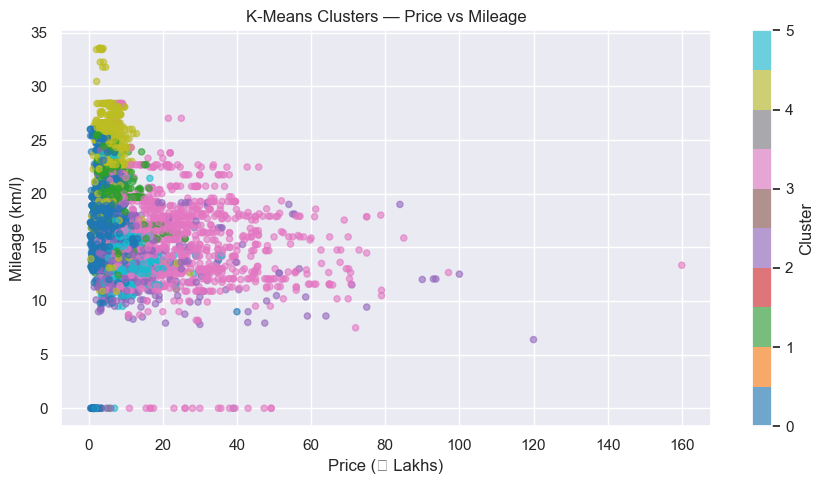

In [13]:
# Cluster visualisation (Price vs Mileage)
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    df['Price'], df['Mileage(Km/L)'],
    c=df['cluster'], cmap='tab10', alpha=0.6, s=20
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Price (₹ Lakhs)')
plt.ylabel('Mileage (km/l)')
plt.title('K-Means Clusters — Price vs Mileage')
plt.tight_layout()
plt.show()

In [14]:
def recommend_kmeans(user_input, df, kmeans_model, scaler, X_columns, n=5):
    """
    Assign user to a cluster, then recommend cars from that cluster.
    """
    user_df = pd.DataFrame([user_input])
    user_df = pd.get_dummies(user_df)
    user_df = user_df.reindex(columns=X_columns, fill_value=0)
    user_vec = scaler.transform(user_df)

    user_cluster = kmeans_model.predict(user_vec)[0]
    cluster_cars = df[df['cluster'] == user_cluster].copy()

    # Sort by price proximity
    cluster_cars['price_diff'] = (cluster_cars['Price'] - user_input['Price']).abs()
    return (cluster_cars
            .sort_values('price_diff')
            .drop_duplicates(subset='Name')
            .head(n)
            .reset_index(drop=True))


kmeans_results = recommend_kmeans(user_input_knn, df, kmeans, scaler, X.columns)
print('K-Means Cluster Recommendations:')
kmeans_results[['Name', 'Fuel_Type', 'Transmission', 'Engine(CC)',
                'Mileage(Km/L)', 'Price', 'cluster']]

K-Means Cluster Recommendations:


,Name,Fuel_Type,Transmission,Engine(CC),Mileage(Km/L),Price,cluster
0,Honda Amaze SX i-VTEC,Petrol,Manual,1198,17.80,5.0,0
1,Ford Figo 1.2P Titanium MT,Petrol,Manual,1196,18.16,5.0,0
2,Hyundai Grand i10 Asta Option,Petrol,Manual,1197,18.90,5.0,0
3,Tata Tiago 1.2 Revotron XZ WO Alloy,Petrol,Manual,1199,23.84,5.0,0
4,Honda Civic 2010-2013 1.8 S MT,Petrol,Manual,1799,14.80,5.0,0


## 7. Evaluation

In [16]:
# ── 7a. Intra-list Diversity ─────────────────────────────────────────────────
# How spread out are the recommended prices?
# A good recommender shouldn't return 5 identical cars.

def price_diversity(results_df):
    return round(float(results_df['Price'].std()), 3)

print('Price std-dev (higher = more diverse):')
print('  KNN:     ', price_diversity(knn_results))
print('  Cosine:  ', price_diversity(cosine_results))
print('  K-Means: ', price_diversity(kmeans_results))

Price std-dev (higher = more diverse):
  KNN:      0.172
  Cosine:   0.411
  K-Means:  0.0


In [17]:
# ── 7b. Mean Absolute Price Error ────────────────────────────────────────────
# Average deviation from user's budget across recommended cars

def mean_price_error(results_df, user_price):
    return round(float((results_df['Price'] - user_price).abs().mean()), 3)

up = user_input_knn['Price']
print(f'Mean |Price - Budget| (lower = closer to budget of ₹{up}L):')
print('  KNN:     ', mean_price_error(knn_results, up))
print('  Cosine:  ', mean_price_error(cosine_results, up))
print('  K-Means: ', mean_price_error(kmeans_results, up))

Mean |Price - Budget| (lower = closer to budget of ₹5.0L):
  KNN:      0.107
  Cosine:   0.356
  K-Means:  0.0


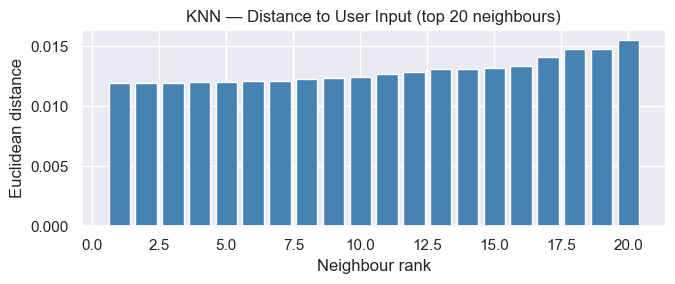

In [18]:
# ── 7c. KNN Distance Distribution ───────────────────────────────────────────
# Visualise how far neighbours are — ideally a tight cluster near 0

user_df_eval = pd.DataFrame([user_input_knn])
user_df_eval = pd.get_dummies(user_df_eval)
user_df_eval = user_df_eval.reindex(columns=X.columns, fill_value=0)
user_vec_eval = scaler.transform(user_df_eval)

distances_all, _ = knn_model.kneighbors(user_vec_eval, n_neighbors=20)
dists = distances_all[0]

plt.figure(figsize=(7, 3))
plt.bar(range(1, len(dists)+1), dists, color='steelblue')
plt.xlabel('Neighbour rank')
plt.ylabel('Euclidean distance')
plt.title('KNN — Distance to User Input (top 20 neighbours)')
plt.tight_layout()
plt.show()

In [19]:
# ── 7d. Silhouette Score (K-Means quality) ───────────────────────────────────
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, df['cluster'], sample_size=2000, random_state=42)
print(f'K-Means Silhouette Score (k={OPTIMAL_K}): {sil:.4f}')
print('  > 0.5 = strong clusters, 0.2–0.5 = reasonable, < 0.2 = weak')

K-Means Silhouette Score (k=6): 0.3275
  > 0.5 = strong clusters, 0.2–0.5 = reasonable, < 0.2 = weak


In [20]:
# ── 7e. Side-by-side comparison of all three methods ─────────────────────────
print('=' * 60)
print('USER INPUT:')
for k, v in user_input_knn.items():
    print(f'  {k}: {v}')
print()

for label, res in [('KNN', knn_results),
                   ('Cosine', cosine_results),
                   ('K-Means', kmeans_results)]:
    print(f'── {label} Recommendations ──')
    for _, row in res.iterrows():
        print(f"  {row['Name']:<35} ₹{row['Price']:.2f}L  "
              f"{row['Fuel_Type']:<8} {row['Mileage(Km/L)']:.1f} km/l")
    print()

USER INPUT:
  Manufacturer: Maruti
  Fuel_Type: Petrol
  Transmission: Manual
  Engine(CC): 1200
  Mileage(Km/L): 20.0
  Seats: 5
  Price: 5.0

── KNN Recommendations ──
  Maruti Swift VXI BSIV               ₹5.00L  Petrol   20.4 km/l
  Maruti Swift ZXI                    ₹4.95L  Petrol   20.4 km/l
  Maruti Swift VXI Optional           ₹5.27L  Petrol   20.4 km/l

── Cosine Recommendations ──
  Maruti Swift Dzire VXI              ₹5.25L  Petrol   20.9 km/l
  Maruti Swift LXI                    ₹4.65L  Petrol   18.6 km/l
  Maruti Swift Dzire VXI Optional     ₹4.80L  Petrol   20.9 km/l
  Maruti Swift VVT VXI                ₹5.43L  Petrol   22.0 km/l
  Maruti Swift ZXI                    ₹4.45L  Petrol   18.6 km/l

── K-Means Recommendations ──
  Honda Amaze SX i-VTEC               ₹5.00L  Petrol   17.8 km/l
  Ford Figo 1.2P Titanium MT          ₹5.00L  Petrol   18.2 km/l
  Hyundai Grand i10 Asta Option       ₹5.00L  Petrol   18.9 km/l
  Tata Tiago 1.2 Revotron XZ WO Alloy ₹5.00L  Petrol  

## 8. Save Artefacts

In [21]:
import pickle, os

os.makedirs('../models', exist_ok=True)

with open('../models/knn_model.pkl', 'wb')  as f: pickle.dump(knn_model, f)
with open('../models/scaler.pkl',    'wb')  as f: pickle.dump(scaler,    f)
with open('../models/columns.pkl',   'wb')  as f: pickle.dump(X.columns, f)
with open('../models/kmeans.pkl',    'wb')  as f: pickle.dump(kmeans,    f)

# Save cleaned dataset (used at runtime by the Streamlit app)
df.to_csv('../data/cars_clean.csv', index=False)

print('All artefacts saved to /models/ ✅')
print('Cleaned dataset saved to data/cars_clean.csv ✅')

All artefacts saved to /models/ ✅
Cleaned dataset saved to data/cars_clean.csv ✅
